## This spanish script makes the statics stability analysis for the airfoil: NACA 4412

### Author: Samuel David Gómez Hernández

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

**----> Caracteristicas del perfil alar <----**

In [7]:
class Airfoil:
  def __init__(self, archivo):
    self.archivo = archivo

  def datos (self):
    # Abrir archivo y filtrar líneas con datos numéricos
    with open(self.archivo, "r") as f:
      lineas = f.readlines()
    datos = []
    for linea in lineas:
        # Saltar líneas que no empiecen con número o espacio seguido de número
        if not linea.strip() or not (linea.strip()[0].isdigit() or linea.strip()[0] == '-'):
            continue

        partes = linea.split()
        try:
            alpha = float(partes[0])
            cl = float(partes[1])
            datos.append([alpha*np.pi/180, cl])
        except:
            pass  # ignora líneas que no sean válidas numéricamente

    #Convertir a array numpy (opcional)
    return np.array(datos)


  def CL_0 (self):
    # Sacamos los datos de cl0 del perfil
    matriz_cl = self.datos()
    for i in range(len(matriz_cl)):
      if (matriz_cl[i][0] == 0):
        CL_w0 = matriz_cl[i][1]
    print("Coeficiente de sustentación a cero angulo de ataque:")
    print(CL_w0)
    return CL_w0

  def promedio_mcl (self):
   matriz_cl = self.datos()
   # Lista para guardar las pendientes (ΔCL/Δα)
   m_cl_1 = []
   # Recorremos los primeros 12 puntos
   for i in range(12):
      ΔCL = matriz_cl[i+1][1] - matriz_cl[i][1]
      Δα  = matriz_cl[i+1][0] - matriz_cl[i][0]
      pendiente = ΔCL / Δα
      m_cl_1.append(pendiente)
   m_cl = np.array(m_cl_1)
   #Mostrar resultados
   print("Pendiente:")
   promedio_mcl = np.mean(m_cl)
   print(promedio_mcl)
   return promedio_mcl


Naca4412 = Airfoil('Data/NACA 4412-RE70.txt')
print("Matriz [alpha, CL]:")
print(Naca4412.datos())

Matriz [alpha, CL]:
[[-0.08726646 -0.0737    ]
 [-0.06981317  0.0364    ]
 [-0.05235988  0.146     ]
 [-0.03490659  0.2558    ]
 [-0.01745329  0.3641    ]
 [ 0.          0.4608    ]
 [ 0.01745329  0.5902    ]
 [ 0.03490659  0.6936    ]
 [ 0.05235988  0.7992    ]
 [ 0.06981317  0.9048    ]
 [ 0.08726646  1.0091    ]
 [ 0.10471976  1.1089    ]
 [ 0.12217305  1.2058    ]
 [ 0.13962634  1.2933    ]
 [ 0.15707963  1.3536    ]
 [ 0.17453293  1.3843    ]
 [ 0.19198622  1.4115    ]
 [ 0.20943951  1.4365    ]
 [ 0.2268928   1.4385    ]
 [ 0.2443461   1.4495    ]
 [ 0.26179939  1.4313    ]
 [ 0.27925268  1.4363    ]
 [ 0.29670597  1.4295    ]
 [ 0.31415927  1.4143    ]
 [ 0.33161256  1.3741    ]
 [ 0.34906585  1.3397    ]]


**----> Calculos de Cm para las alas <----**


In [8]:
#Definición de los parametros del VTOL
AR = 9.33 #Aspect Ratio
c_mean = 0.252  #Cuerda media aerodinámica (MAC) del ala [m]
ct = 0.16   #Cuerda del estabilizador horizontal (cola) [m]
b_t = 0.86 #Envergadura del estabilizador horizontal [m]
iw = 0*np.pi/180 #Angulo de incidencia del ala respecto al fuselaje [rad]
it = -2*np.pi/180 #Angulo de incidencia del estabilizador horizontal [rad]
S = 0.567 #Superficie alar total (área de referencia del ala)
St = ct*b_t #Superficie del estabilizador horizontal

#Definicion del perfil del ala
Perfil = "NACA4412"
NACA4412 = Airfoil('Data/NACA 4412-RE70.txt')
CL_w0 = NACA4412.CL_0() # CL del ala a α = 0° → 0.4608
promedio_mcl = NACA4412.promedio_mcl() ## Pendiente de la curva de sustentación CLα [1/rad]

# Cm_ac: coeficiente de momento de cabeceo alrededor del centro aerodinámico del perfil.
# Se mide al 25% de la cuerda (cuarto de cuerda). Aproximación válida hasta α ≈ 8°.
# Valor negativo = tendencia nose-down (típico de perfiles con camber).
if(Perfil == "SD7032"):
  Cm_acw = -0.099 #Sacado del vol.1 de datos de la universidad de illinois
elif(Perfil  == "NACA4412"):
  Cm_acw = -0.1 
 
# =====================================================================
# POSICIONES LONGITUDINALES Y VERTICALES (medidas desde el morro)
# Convención: X positivo hacia la cola, Z positivo hacia arriba
# =====================================================================
xcg = 0.41 # Posición longitudinal del centro de gravedad (CG) desde el morro [m]
zcg = 0    # Posición vertical del CG respecto al eje de referencia [m] (asumido en la línea central)
xw = 0.4   # Posición longitudinal del borde de ataque (leading edge) del ala desde el morro [m]
zacw = 0   # Posición vertical del centro aerodinámico del ala [m] (asumido coplanar con CG)

xacw = 0.25*c_mean + xw #xacw: Posicion longitudinal del centro areodinamico con respecto al morro // xw = Distancia borde de ataque - morro
xact = 1.2 #Posicion longitudinal del centro areodinamico de la cola
zact = 0    # Posición vertical del AC del estabilizador horizontal [m]

#Definicíon de coordenadas de los puntos de referencia
c_morro = [0, 0]  #Origen: punta del morro (datum de referencia)
c_cg = [xcg, zcg] #Posicion del centro de gravedad, [0.41, 0] m
c_acw = [xacw, zacw] #Posicion del centro areodinamico de las alas, [0.463, 0] m
c_act = [xact, zact] #Posicion del centro aerodinamico del estabulizador H, [1.20, 0] m


CL_w = [] #Lista de CL del ala para cada α
alpha_deg = []  #Angulo de ataque absoluto [grados]
Cm_wing_list = [] #Coeficiente de momento del ala alrededor del CG para cada α
angulo_fuselaje = [] #Angulo de ataque del fuselaje [grados]

for i in range(20):
  alpha = (-5 + (i*1))*np.pi/180 #Angulo de ataque [rad]
  
  CL_w_argumento = CL_w0 + ((alpha)*promedio_mcl)
  CL_w.append(CL_w_argumento)
  
  
  #Momento de cabeceo del ala alrededor del CG
  Cm_wing = (CL_w[i]*((c_cg[0]-c_acw[0])/c_mean)*np.cos(alpha-iw)) + (CL_w[i]*(((c_cg[1]-c_acw[1])/c_mean)*np.sin(alpha+iw))) + Cm_acw
  alpha_deg.append((alpha)*180/np.pi)
  angulo_fuselaje.append((alpha-iw)*180/np.pi)
  Cm_wing_list.append(Cm_wing)

# Diagnóstico: distancia AC_w → CG (negativa = CG delante del AC = estable)
# y posición absoluta del AC del ala
print("Distancia (xacw - xcg):", (xacw - xcg), "| xacw:", xacw)
# Resultado: 0.053 m → CG está 5.3 cm DELANTE del AC del ala
# Esto significa que el ala sola genera un Cm negativo (nose-down) al aumentar α → contribución estabilizante

Coeficiente de sustentación a cero angulo de ataque:
0.4608
Pendiente:
6.109162490582402
Distancia (xacw - xcg): 0.05300000000000005 | xacw: 0.463


**----> Calculos de Cm para la cola <----**

In [11]:
#Definicion del perfil de la cola
NACA0012 = Airfoil('Data/NACA 0012-RE70.txt')
promedio_mcl_t = NACA0012.promedio_mcl()

Cm_act = 0 #Coeficiente de momento del perfil de cola alrededor de su propio AC
# = 0 porque el NACA 0012 es simétrico (sin camber → no genera momento propio)


lt = xact-xcg #Brazo de momento de la cola: distancia del AC del estabilizador al CG [m]
V_H = lt*St/(S*c_mean)
#Coeficiente de volumen horizontal del estabilizador  
#V_H = (0.79 × 0.1376) / (0.567 × 0.252) = 0.761
#Mide la "efectividad" de la cola: combina su tamaño relativo y su brazo de momento
#Valores típicos para aviones convencionales: 0.3 - 0.6
#El valor de 0.761 es alto → cola relativamente grande o lejana

# Relación de presión dinámica en la cola
eta = 1 #Debido a que no sabemos como será el efecto de la estela due to lift + el rebufo del propeller

e_0 = 2*CL_w0/(np.pi*AR)  #Downwash a sustentación cero [rad]
m_e = 2*promedio_mcl/(np.pi*AR) #Gradiente de downwash

alpha_t_deg = [] #Angulo de ataque efectivo de la cola [grados]
CL_t = []  #Coeficiente de sustentación de la cola para cada α
Cm_t_list = []  #Coeficiente de momento de la cola alrededor del CG para cada α

for i in range(20):
  e = 0 #e_0 + m_e*(alpha_deg[i]*np.pi/180) [rad]
  alpha_t = (alpha_deg[i]*np.pi/180) - iw - e + it #[rad]
  alpha_t_deg.append(alpha_t*180/np.pi)
  
  CL_t_argumento = (alpha_t_deg[i]*np.pi/180)*promedio_mcl_t
  CL_t.append(CL_t_argumento)
  
  Cm_tail = -V_H*eta*CL_t[i] + Cm_act #Momento de cabeceo de la cola alrededor del CG
  Cm_t_list.append(Cm_tail)

#PUNTO NEUTRO (Neutral Point, XNP)
#El punto neutro es la posición del CG donde el margen estático = 0.
#Si el CG está delante del NP → estáticamente estable (dCm/dα < 0)
#Si el CG está detrás del NP → estáticamente inestable

#Formula:
#XNP = x_acw + x_w - c̄ × V_H × η × (CLα_t / CLα_w)
#Margen estatico = (XNP - xcg) / c̄
XNP = xacw - c_mean*V_H*eta*(promedio_mcl_t/promedio_mcl) + xw
print("El punto neutro es:",XNP) #Punto neutro desde el morro
print("El brazo de momento de la cola es:",lt)  #Brazo de momento de la cola
print("El coeficiente de volumen horizontal es:",V_H) #Coeficiente de volumen horizontal

Pendiente:
6.805783676495628
El punto neutro es: 0.649420812252361
El brazo de momento de la cola es: 0.79
El coeficiente de volumen horizontal es: 0.7607849724251842


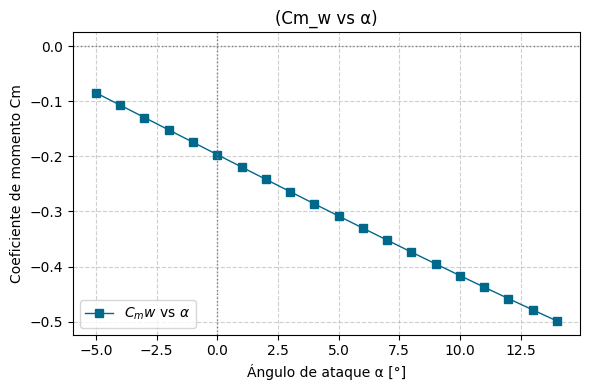

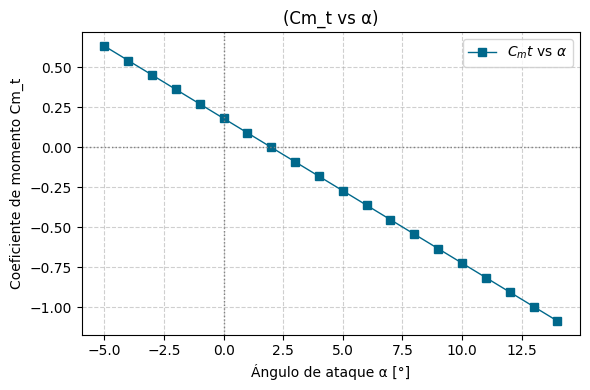

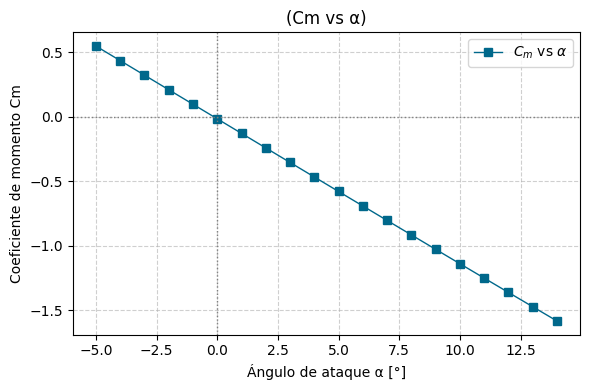

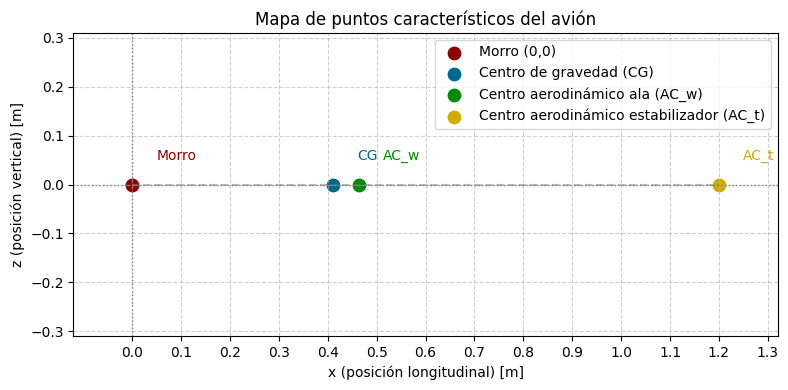

El ángulo donde Cm = 0 es aproximadamente: -0.143°


In [12]:
# --- Gráfica Cm_w vs alpha ---
plt.figure(figsize=(6,4))
plt.plot(angulo_fuselaje, Cm_wing_list, marker='s', color='#00688b', label='$C_mw$ vs $\\alpha$', linewidth=1)
plt.title("(Cm_w vs α)")
plt.xlabel("Ángulo de ataque α [°]")
plt.ylabel("Coeficiente de momento Cm")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.axhline(0, color='gray', linestyle=':', linewidth=1)
plt.axvline(0, color='gray', linestyle=':', linewidth=1)
plt.tight_layout()
plt.show()

# 🟦 Espacio visual entre figuras
display(HTML("<br><br><hr><br><br>"))

# --- Gráfica Cm_t vs alpha ---
plt.figure(figsize=(6,4))
plt.plot(angulo_fuselaje, Cm_t_list, marker='s', color='#00688b', label='$C_mt$ vs $\\alpha$', linewidth=1)
plt.title("(Cm_t vs α)")
plt.xlabel("Ángulo de ataque α [°]")
plt.ylabel("Coeficiente de momento Cm_t")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.axhline(0, color='gray', linestyle=':', linewidth=1)
plt.axvline(0, color='gray', linestyle=':', linewidth=1)
plt.tight_layout()
plt.show()

# 🟦 Espacio visual entre figuras
display(HTML("<br><br><hr><br><br>"))

# --- Gráfica Cm_cg vs alpha ---
plt.figure(figsize=(6,4))
#Verificar esa grafia
plt.plot(angulo_fuselaje, np.array(Cm_t_list) + np.array(Cm_wing_list), marker='s', color='#00688b', label='$C_m$ vs $\\alpha$', linewidth=1)
plt.title("(Cm vs α)")
plt.xlabel("Ángulo de ataque α [°]")
plt.ylabel("Coeficiente de momento Cm")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.axhline(0, color='gray', linestyle=':', linewidth=1)
plt.axvline(0, color='gray', linestyle=':', linewidth=1)
plt.tight_layout()
plt.show()

# 🟦 Espacio visual entre figuras
display(HTML("<br><br><hr><br><br>"))

# --- Gráfica de puntos ---
plt.figure(figsize=(8,4))
plt.scatter(*c_morro, color='#8b0000', s=80, label='Morro (0,0)')
plt.scatter(*c_cg, color='#00688b', s=80, label='Centro de gravedad (CG)')
plt.scatter(*c_acw, color='#008b00', s=80, label='Centro aerodinámico ala (AC_w)')
plt.scatter(*c_act, color='#cdad00', s=80, label='Centro aerodinámico estabilizador (AC_t)')

# Líneas de referencia
plt.plot([c_morro[0], c_act[0]], [c_morro[1], c_act[1]], '--', color='gray', alpha=0.5)
plt.axhline(0, color='gray', linestyle=':', linewidth=1)
plt.axvline(0, color='gray', linestyle=':', linewidth=1)

# Etiquetas
plt.text(c_morro[0]+0.05, c_morro[1]+0.05, "Morro", color='#8b0000')
plt.text(c_cg[0]+0.05, c_cg[1]+0.05, "CG", color='#00688b')
plt.text(c_acw[0]+0.05, c_acw[1]+0.05, "AC_w", color='#008b00')
plt.text(c_act[0]+0.05, c_act[1]+0.05, "AC_t", color='#cdad00')

plt.title("Mapa de puntos característicos del avión")
plt.xlabel("x (posición longitudinal) [m]")
plt.ylabel("z (posición vertical) [m]")
################## Revisar esto para poner mas bonitas las graficas #######################
plt.xticks(np.arange(0, 1.5, 0.1))
plt.xlim(0, 1)
plt.margins(x=0.1, y=0.2)
#########################################
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

####################################################################################################################################

# Convertir a arrays
alpha = np.array(angulo_fuselaje)
Cm = np.array(Cm_t_list) + np.array(Cm_wing_list)

# ---- Encontrar α donde Cm = 0 ----
# Cambios de signo indican un cruce por cero
sign_changes = np.where(np.diff(np.sign(Cm)) != 0)[0]

if len(sign_changes) > 0:
    i = sign_changes[0]  # primer cruce
    # Interpolación lineal
    alpha_zero = alpha[i] + (0 - Cm[i]) * (alpha[i+1] - alpha[i]) / (Cm[i+1] - Cm[i])
    print(f"El ángulo donde Cm = 0 es aproximadamente: {alpha_zero:.3f}°")
else:
    print("No se encontró un cruce por cero en los datos.")